# Idea

What I want is a way of connecting Bayes Nets and Markov Decision Processes, so that I can take the environment to be a BN with a do operator, and the MDP adds the rest.


Ideas:
- A state in the MDP corresponds to a value assignment to the variables in the Bayes Net.
- What is the relation between the transition probabilities in the MDP and the conditional probabilities of the causal variables in the MDP?
- What is the relation between the do-operator in the do-calculus and the actions in the MDP?

Personas trabajando en esto:
- https://www.tomeveritt.se/

P(C=1) = 0.6950
P(B=0) = 0.4100


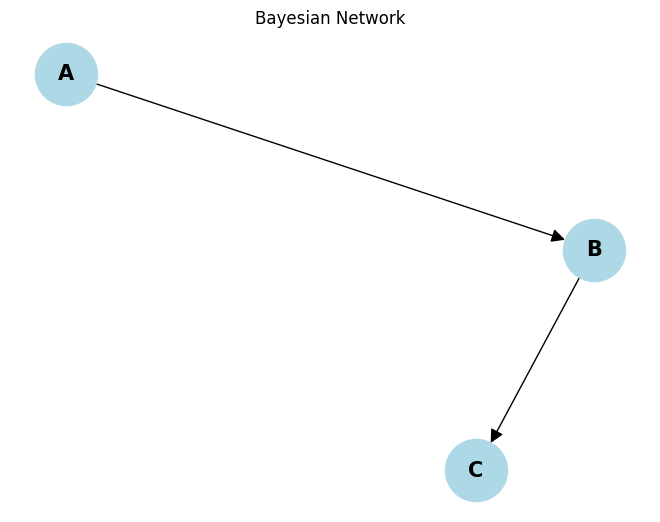

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

class BayesianNetwork:
    def __init__(self):
        # Initialize the structure of the network (a dictionary where keys are parent nodes
        # and values are lists of child nodes) and the CPDs (Conditional Probability Distributions).
        self.structure = {}
        self.cpds = {}
        self.variables = set()

    def add_edge(self, parent, child):
        # Add an edge from parent to child in the network structure.
        if parent not in self.structure:
            self.structure[parent] = []
        self.structure[parent].append(child)
        # Add the parent and child to the set of variables.
        self.variables.update([parent, child])

    def set_cpd(self, variable, cpd):
        # Set the CPD for a given variable.
        self.cpds[variable] = cpd
        # Add the variable to the set of variables.
        self.variables.add(variable)

    def get_parents(self, variable):
        # Get the list of parent nodes for a given variable.
        parents = []
        for parent, children in self.structure.items():
            if variable in children:
                parents.append(parent)
        return parents

    def joint_probability(self, assignment):
        # Calculate the joint probability of a given assignment of variables.
        jp = 1.0
        for variable in self.variables:
            parents = self.get_parents(variable)
            if not parents:
                # If the variable has no parents, use its prior probability.
                jp *= self.cpds[variable][assignment[variable]]
            else:
                # If the variable has parents, use its conditional probability given the parents' values.
                parent_assignment = tuple(assignment[parent] for parent in parents)
                jp *= self.cpds[variable][parent_assignment][assignment[variable]]
        return jp

    def marginal_probability(self, variable, value):
        # Calculate the marginal probability of a variable taking a specific value.
        marginal_prob = 0.0
        # Generate all possible assignments of variables.
        all_assignments = self.generate_all_assignments()
        for assignment in all_assignments:
            if assignment[variable] == value:
                # Sum the joint probabilities of all assignments where the variable has the desired value.
                marginal_prob += self.joint_probability(assignment)
        return marginal_prob

    def generate_all_assignments(self):
        # Generate all possible assignments of variables (all combinations of 0 and 1).
        import itertools
        variables = list(self.variables)
        all_combinations = list(itertools.product([0, 1], repeat=len(variables)))
        all_assignments = [dict(zip(variables, combination)) for combination in all_combinations]
        return all_assignments

    def plot(self):
        # Create a directed graph
        G = nx.DiGraph()
        # Add edges to the graph
        for parent, children in self.structure.items():
            for child in children:
                G.add_edge(parent, child)
        # Draw the graph
        pos = nx.spring_layout(G)  # Compute positions for the nodes
        nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue',
                font_size=15, font_weight='bold', arrowsize=20)  # Draw the graph with labels
        plt.title("Bayesian Network")  # Set the title of the plot
        plt.show()  # Display the plot

# Create a Bayesian Network
bn = BayesianNetwork()

# Add edges to define the structure of the network
bn.add_edge('A', 'B')
bn.add_edge('B', 'C')

# Define CPDs (Conditional Probability Distributions) for each variable
# P(A)
bn.set_cpd('A', {0: 0.3, 1: 0.7})

# P(B | A)
bn.set_cpd('B', {
    (0,): {0: 0.9, 1: 0.1},
    (1,): {0: 0.2, 1: 0.8}
})

# P(C | B)
bn.set_cpd('C', {
    (0,): {0: 0.6, 1: 0.4},
    (1,): {0: 0.1, 1: 0.9}
})

# Compute marginal probability P(C = 1)
marginal_prob_c1 = bn.marginal_probability('C', 1)
print(f"P(C=1) = {marginal_prob_c1:.4f}")

# Compute marginal probability P(B = 0)
marginal_prob_b0 = bn.marginal_probability('B', 0)
print(f"P(B=0) = {marginal_prob_b0:.4f}")

# Plot the Bayesian Network
bn.plot()


P(E=1) = 0.4478
P(D=0) = 0.6000


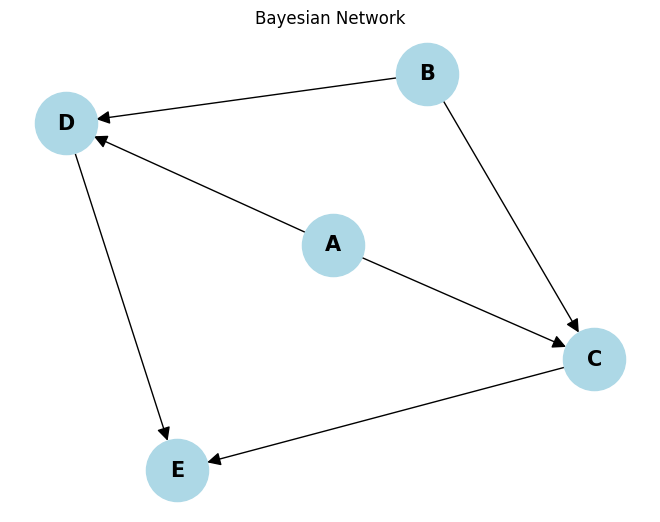

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

class BayesianNetwork:
    def __init__(self):
        # Initialize the structure of the network (a dictionary where keys are parent nodes
        # and values are lists of child nodes) and the CPDs (Conditional Probability Distributions).
        self.structure = {}
        self.cpds = {}
        self.variables = set()

    def add_edge(self, parent, child):
        # Add an edge from parent to child in the network structure.
        if parent not in self.structure:
            self.structure[parent] = []
        self.structure[parent].append(child)
        # Add the parent and child to the set of variables.
        self.variables.update([parent, child])

    def set_cpd(self, variable, cpd):
        # Set the CPD for a given variable.
        self.cpds[variable] = cpd
        # Add the variable to the set of variables.
        self.variables.add(variable)

    def get_parents(self, variable):
        # Get the list of parent nodes for a given variable.
        parents = []
        for parent, children in self.structure.items():
            if variable in children:
                parents.append(parent)
        return parents

    def joint_probability(self, assignment):
        # Calculate the joint probability of a given assignment of variables.
        jp = 1.0
        for variable in self.variables:
            parents = self.get_parents(variable)
            if not parents:
                # If the variable has no parents, use its prior probability.
                jp *= self.cpds[variable][assignment[variable]]
            else:
                # If the variable has parents, use its conditional probability given the parents' values.
                parent_assignment = tuple(assignment[parent] for parent in parents)
                jp *= self.cpds[variable][parent_assignment][assignment[variable]]
        return jp

    def marginal_probability(self, variable, value):
        # Calculate the marginal probability of a variable taking a specific value.
        marginal_prob = 0.0
        # Generate all possible assignments of variables.
        all_assignments = self.generate_all_assignments()
        for assignment in all_assignments:
            if assignment[variable] == value:
                # Sum the joint probabilities of all assignments where the variable has the desired value.
                marginal_prob += self.joint_probability(assignment)
        return marginal_prob

    def generate_all_assignments(self):
        # Generate all possible assignments of variables (all combinations of 0 and 1).
        import itertools
        variables = list(self.variables)
        all_combinations = list(itertools.product([0, 1], repeat=len(variables)))
        all_assignments = [dict(zip(variables, combination)) for combination in all_combinations]
        return all_assignments

    def plot(self):
        # Create a directed graph
        G = nx.DiGraph()
        # Add edges to the graph
        for parent, children in self.structure.items():
            for child in children:
                G.add_edge(parent, child)
        # Draw the graph
        pos = nx.spring_layout(G)  # Compute positions for the nodes
        nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue',
                font_size=15, font_weight='bold', arrowsize=20)  # Draw the graph with labels
        plt.title("Bayesian Network")  # Set the title of the plot
        plt.show()  # Display the plot

# Create a Bayesian Network
bn = BayesianNetwork()

# Add edges to define the structure of the network
bn.add_edge('A', 'C')
bn.add_edge('A', 'D')
bn.add_edge('B', 'C')
bn.add_edge('B', 'D')
bn.add_edge('C', 'E')
bn.add_edge('D', 'E')

# Define CPDs (Conditional Probability Distributions) for each variable
# P(A)
bn.set_cpd('A', {0: 0.4, 1: 0.6})

# P(B)
bn.set_cpd('B', {0: 0.7, 1: 0.3})

# P(C | A, B)
bn.set_cpd('C', {
    (0, 0): {0: 0.8, 1: 0.2},
    (0, 1): {0: 0.7, 1: 0.3},
    (1, 0): {0: 0.4, 1: 0.6},
    (1, 1): {0: 0.1, 1: 0.9}
})

# P(D | A, B)
bn.set_cpd('D', {
    (0, 0): {0: 0.9, 1: 0.1},
    (0, 1): {0: 0.5, 1: 0.5},
    (1, 0): {0: 0.6, 1: 0.4},
    (1, 1): {0: 0.2, 1: 0.8}
})

# P(E | C, D)
bn.set_cpd('E', {
    (0, 0): {0: 0.9, 1: 0.1},
    (0, 1): {0: 0.6, 1: 0.4},
    (1, 0): {0: 0.5, 1: 0.5},
    (1, 1): {0: 0.1, 1: 0.9}
})

# Compute marginal probability P(E = 1)
marginal_prob_e1 = bn.marginal_probability('E', 1)
print(f"P(E=1) = {marginal_prob_e1:.4f}")

# Compute marginal probability P(D = 0)
marginal_prob_d0 = bn.marginal_probability('D', 0)
print(f"P(D=0) = {marginal_prob_d0:.4f}")

# Plot the Bayesian Network
bn.plot()
